In [1]:
# Regularization model ki complexity ko penalize karti hai taake model training data ko unnecessarily memorize na kare.

In [2]:
# "Sirf data fit karne ki koshish mat karo. Simple rehne ki bhi koshish karo."
# Conceptually:

# Normal training:

# Loss = prediction error


# Regularized training:

# Loss = prediction error + complexity penalty

# Model ab dono cheezein minimize karega:

# Prediction error
# Model complexity

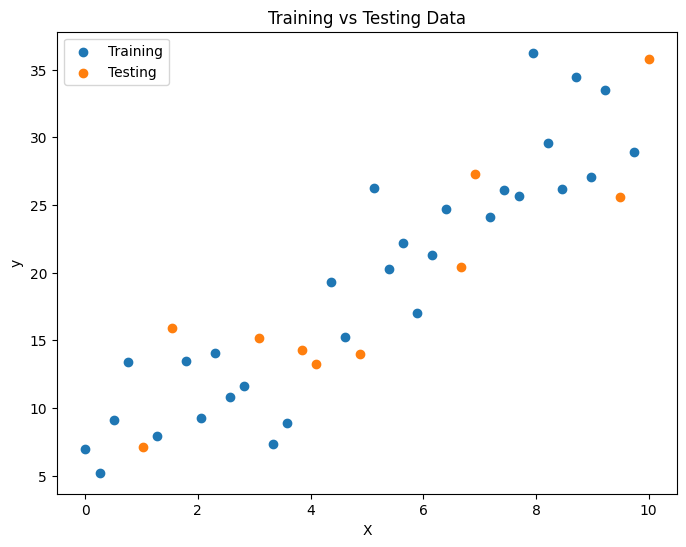

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Generate data
np.random.seed(42)

X = np.linspace(0, 10, 40).reshape(-1, 1)

y = (
    3 * X[:, 0]
    + 5
    + np.random.normal(0, 4, 40)
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training"
)

plt.scatter(
    X_test,
    y_test,
    label="Testing"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Training vs Testing Data")
plt.legend()
plt.show()

In [4]:
model = Pipeline([
    ("poly", PolynomialFeatures(degree=15)),
    ("linear", LinearRegression())
])

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

print(
    "Training MSE:",
    mean_squared_error(y_train, train_pred)
)

print(
    "Testing MSE:",
    mean_squared_error(y_test, test_pred)
)

Training MSE: 8.997924891819798
Testing MSE: 24.144539278897973


In [5]:
# Ridge se control karo
ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=15)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10))
])

ridge_model.fit(X_train, y_train)

ridge_train_pred = ridge_model.predict(X_train)
ridge_test_pred = ridge_model.predict(X_test)

print(
    "Ridge Training MSE:",
    mean_squared_error(y_train, ridge_train_pred)
)

print(
    "Ridge Testing MSE:",
    mean_squared_error(y_test, ridge_test_pred)
)

Ridge Training MSE: 12.944527188662256
Ridge Testing MSE: 15.603774207786469


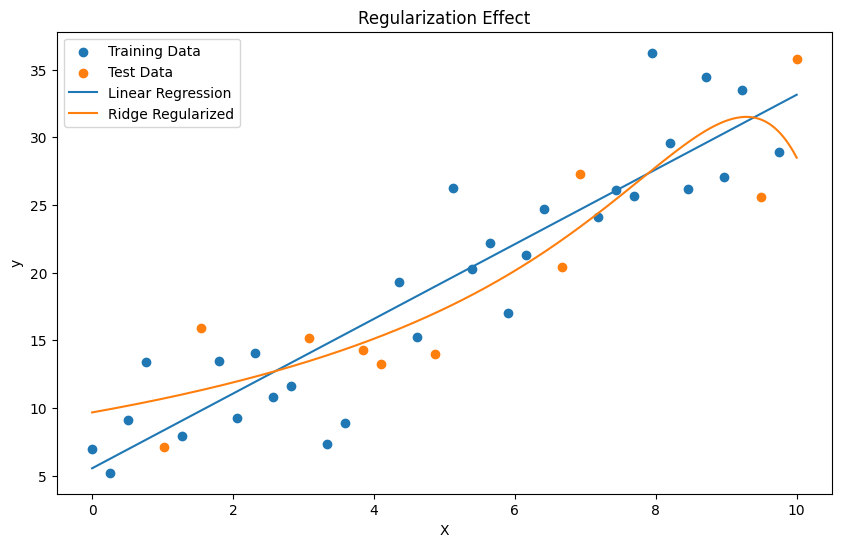

In [6]:
# visualization
x_plot = np.linspace(0, 10, 300).reshape(-1, 1)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

normal_pred = linear_model.predict(x_plot)
ridge_pred = ridge_model.predict(x_plot)

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.scatter(
    X_test,
    y_test,
    label="Test Data"
)

plt.plot(
    x_plot,
    normal_pred,
    label="Linear Regression"
)

plt.plot(
    x_plot,
    ridge_pred,
    label="Ridge Regularized"
)

plt.xlabel("X")
plt.ylabel("y")
plt.title("Regularization Effect")
plt.legend()
plt.show()

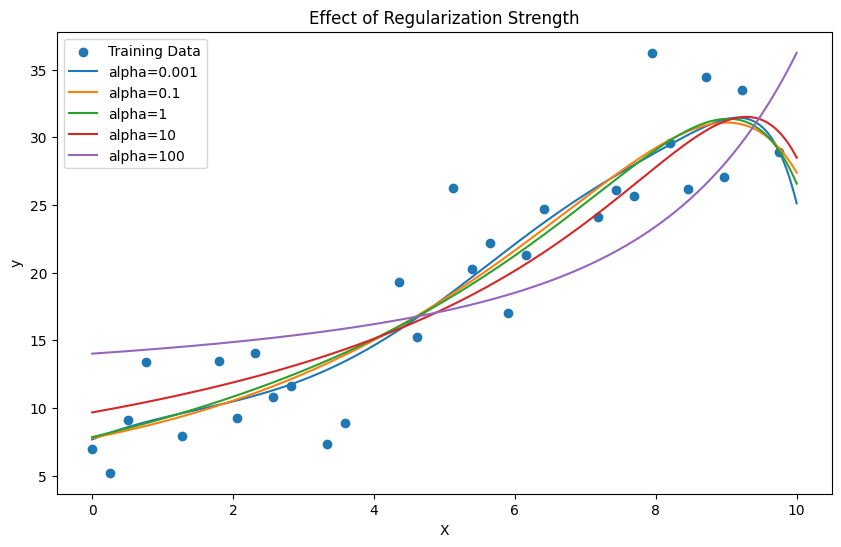

In [7]:
# effect of alpha
alphas = [0.001, 0.1, 1, 10, 100]

plt.figure(figsize=(10, 6))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

for alpha in alphas:

    model = Pipeline([
        ("poly", PolynomialFeatures(degree=15)),
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    prediction = model.predict(x_plot)

    plt.plot(
        x_plot,
        prediction,
        label=f"alpha={alpha}"
    )

plt.xlabel("X")
plt.ylabel("y")
plt.title("Effect of Regularization Strength")
plt.legend()
plt.show()

In [ ]:
# Regularization is a technique used to reduce overfitting by adding a penalty for large model coefficients, encouraging the model to learn simpler patterns that generalize better to unseen data.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.pipeline import Pipeline

# Create dataset
X, y = make_regression(
    n_samples=150,
    n_features=10,
    n_informative=5,
    noise=15,
    random_state=42
)

feature_names = [
    "X1", "X2", "X3", "X4", "X5",
    "X6", "X7", "X8", "X9", "X10"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=10))
])

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=10))
])

elastic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(alpha=10, l1_ratio=0.5))
])

In [10]:
# train all the 4 models
linear_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)
elastic_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', ElasticNet(alpha=10))])

In [11]:
# ab coefficients nikalo
linear_coef = linear_model.named_steps["model"].coef_
ridge_coef = ridge_model.named_steps["model"].coef_
lasso_coef = lasso_model.named_steps["model"].coef_
elastic_coef = elastic_model.named_steps["model"].coef_

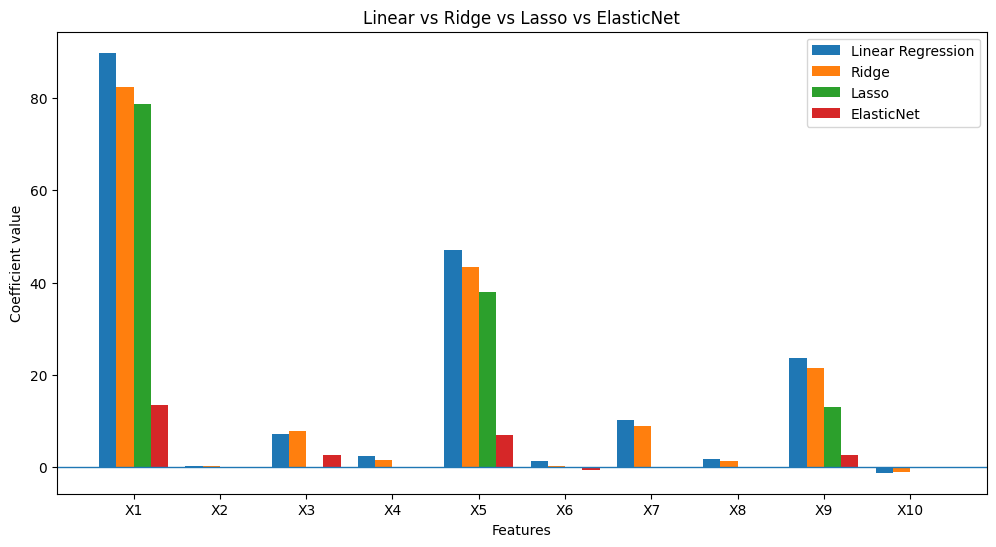

In [12]:
# compare the coefficients
plt.figure(figsize=(12, 6))

x = np.arange(len(feature_names))

width = 0.2

plt.bar(
    x - 1.5 * width,
    linear_coef,
    width,
    label="Linear Regression"
)

plt.bar(
    x - 0.5 * width,
    ridge_coef,
    width,
    label="Ridge"
)

plt.bar(
    x + 0.5 * width,
    lasso_coef,
    width,
    label="Lasso"
)

plt.bar(
    x + 1.5 * width,
    elastic_coef,
    width,
    label="ElasticNet"
)

plt.axhline(0, linewidth=1)

plt.xticks(x, feature_names)

plt.xlabel("Features")
plt.ylabel("Coefficient value")

plt.title("Linear vs Ridge vs Lasso vs ElasticNet")

plt.legend()
plt.show()

In [13]:
# try diff alphas
alphas = [0.01, 0.1, 1, 10, 100]
for alpha in alphas:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    coefficients = model.named_steps["model"].coef_

    print(f"\nAlpha = {alpha}")

    for name, coef in zip(feature_names, coefficients):
        print(f"{name}: {coef:.3f}")



Alpha = 0.01
X1: 89.745
X2: 0.333
X3: 7.107
X4: 2.400
X5: 47.039
X6: 1.256
X7: 10.314
X8: 1.782
X9: 23.557
X10: -1.169

Alpha = 0.1
X1: 89.628
X2: 0.267
X3: 7.024
X4: 2.287
X5: 46.949
X6: 1.173
X7: 10.181
X8: 1.677
X9: 23.443
X10: -1.032

Alpha = 1
X1: 88.463
X2: 0.000
X3: 6.216
X4: 1.153
X5: 46.051
X6: 0.259
X7: 8.858
X8: 0.569
X9: 22.299
X10: -0.000

Alpha = 10
X1: 78.606
X2: 0.000
X3: 0.000
X4: 0.000
X5: 37.907
X6: 0.000
X7: 0.000
X8: 0.000
X9: 13.122
X10: 0.000

Alpha = 100
X1: 0.000
X2: -0.000
X3: 0.000
X4: -0.000
X5: 0.000
X6: -0.000
X7: -0.000
X8: -0.000
X9: 0.000
X10: -0.000


In [14]:
# now for ridge
for alpha in [0.01, 0.1, 1, 10, 100]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)

    coefficients = model.named_steps["model"].coef_

    print(f"\nAlpha = {alpha}")

    for name, coef in zip(feature_names, coefficients):
        print(f"{name}: {coef:.3f}")


Alpha = 0.01
X1: 89.749
X2: 0.341
X3: 7.117
X4: 2.411
X5: 47.045
X6: 1.265
X7: 10.327
X8: 1.793
X9: 23.567
X10: -1.184

Alpha = 0.1
X1: 89.675
X2: 0.339
X3: 7.124
X4: 2.403
X5: 47.009
X6: 1.254
X7: 10.312
X8: 1.788
X9: 23.546
X10: -1.181

Alpha = 1
X1: 88.940
X2: 0.329
X3: 7.194
X4: 2.319
X5: 46.650
X6: 1.145
X7: 10.163
X8: 1.739
X9: 23.332
X10: -1.157

Alpha = 10
X1: 82.232
X2: 0.218
X3: 7.743
X4: 1.596
X5: 43.350
X6: 0.235
X7: 8.836
X8: 1.326
X9: 21.406
X10: -0.943

Alpha = 100
X1: 47.385
X2: -0.504
X3: 7.854
X4: -0.897
X5: 25.496
X6: -2.308
X7: 3.150
X8: 0.031
X9: 11.966
X10: -0.177


In [15]:
# elastic
for ratio in [0, 0.25, 0.5, 0.75, 1]:

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "model",
            ElasticNet(
                alpha=1,
                l1_ratio=ratio
            )
        )
    ])

    model.fit(X_train, y_train)

    coefficients = model.named_steps["model"].coef_

    print(f"\nl1_ratio = {ratio}")

    for name, coef in zip(feature_names, coefficients):
        print(f"{name}: {coef:.3f}")


l1_ratio = 0
X1: 43.359
X2: -0.565
X3: 7.554
X4: -1.029
X5: 23.372
X6: -2.370
X7: 2.649
X8: -0.038
X9: 10.922
X10: -0.129

l1_ratio = 0.25
X1: 49.571
X2: -0.328
X3: 7.856
X4: -0.686
X5: 26.581
X6: -2.113
X7: 3.249
X8: 0.000
X9: 12.423
X10: -0.043

l1_ratio = 0.5
X1: 57.979
X2: -0.000
X3: 8.009
X4: -0.099
X5: 30.868
X6: -1.582
X7: 4.179
X8: 0.000
X9: 14.483
X10: -0.000

l1_ratio = 0.75
X1: 69.987
X2: 0.000
X3: 7.692
X4: 0.000
X5: 36.807
X6: -0.394
X7: 5.770
X8: 0.029
X9: 17.566
X10: -0.000

l1_ratio = 1
X1: 88.463
X2: 0.000
X3: 6.216
X4: 1.153
X5: 46.051
X6: 0.259
X7: 8.858
X8: 0.569
X9: 22.299
X10: -0.000


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.299e+05, tolerance: 1.296e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
